# How many rentals do we need to estimate profitability well?

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

## First CM1 only

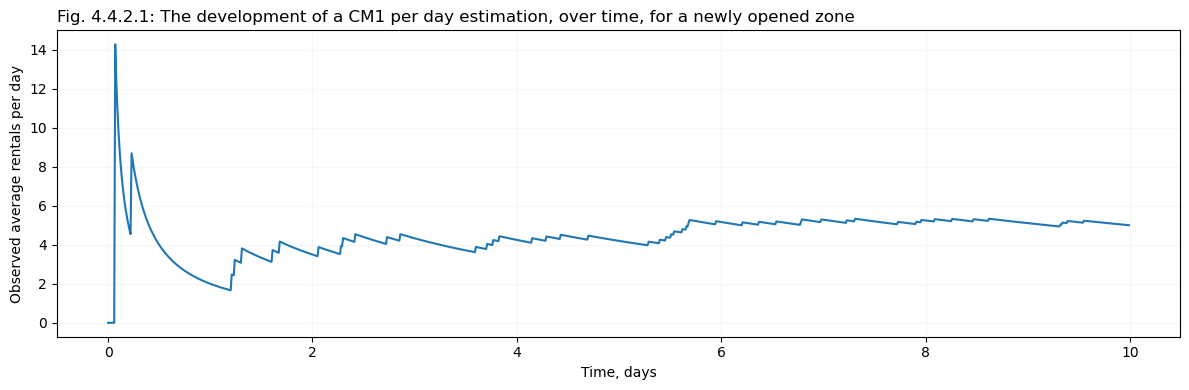

In [231]:
# One CM1 trajectory
N_POINTS = 1000
N_EXPERIMENTS = 1
POINTS_PER_DAY = 100
PROBABILITY = 5/POINTS_PER_DAY

out = np.zeros(shape=(N_POINTS, N_EXPERIMENTS))
for t in range(1, N_POINTS):
    out[t, :] = (out[t-1, :]*(t-1) + (np.random.uniform(size=(1, N_EXPERIMENTS)) < PROBABILITY)*1)/t
out = out*POINTS_PER_DAY # Rescale from rentals per tick to rentals per day

plt.figure(figsize=(12,4))
x = np.arange(N_POINTS)/POINTS_PER_DAY
plt.plot(x, out, color='tab:blue', alpha=1);
plt.xlabel('Time, days')
plt.ylabel('Observed average rentals per day');
plt.title("Fig. 4.4.2.1: The development of a CM1 per day estimation, over time, for a newly opened zone",
          loc='left')
plt.grid(alpha=0.1)

plt.tight_layout()
plt.savefig("../figures/04oa_04growth_02pilots_01cm1_single.svg", dpi=300)

1.6448536269514722

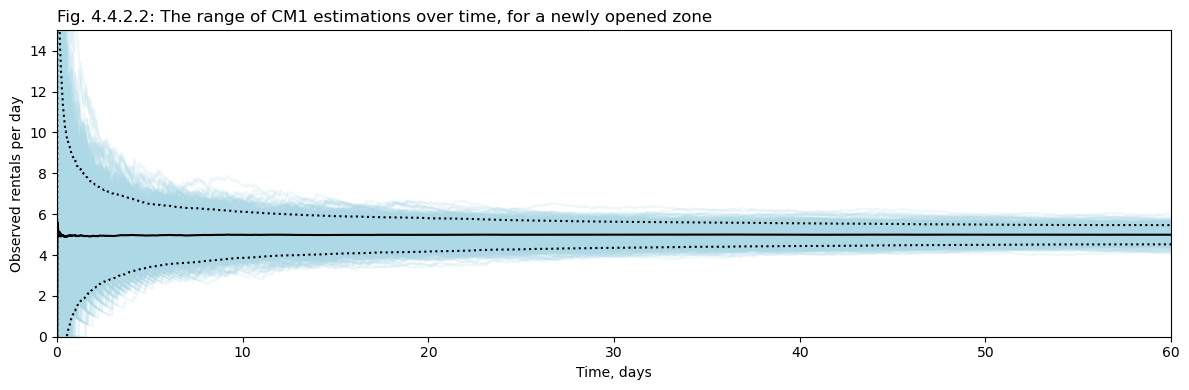

In [230]:
# Many CM1 trajectories
N_POINTS = 6000
N_EXP = 1000
POINTS_PER_DAY = 100
RENTALS_PER_DAY = 5  # Rentals per day
CI = stats.norm.ppf(0.95) # 90% confidence interval (5% on both sides)

out = np.zeros(shape=(N_POINTS, N_EXP))
for t in range(1, N_POINTS):
    out[t, :] = (out[t-1, :]*(t-1) + 
                 (np.random.uniform(size=(1,N_EXP)) < RENTALS_PER_DAY/POINTS_PER_DAY)*1)/t
out = out*POINTS_PER_DAY
x = (np.arange(N_POINTS)+1)/POINTS_PER_DAY

plt.figure(figsize=(12,4))
plt.plot(x, out, color='lightblue', alpha=0.2);
m = out.mean(axis=1)
s = out.std(axis=1)
plt.plot(x, m, 'k-');
plt.plot(x, m-s*CI, 'k:');
plt.plot(x, m+s*CI, 'k:');
plt.ylim(0, 0.15*POINTS_PER_DAY);
plt.xlim(0, N_POINTS // POINTS_PER_DAY);
plt.xlabel('Time, days')
plt.ylabel('Observed rentals per day');
plt.title("Fig. 4.4.2.2: The range of CM1 estimations over time, for a newly opened zone", loc='left')

plt.tight_layout()
plt.savefig("../figures/04oa_04growth_02pilots_02cm1.png", dpi=300) # PNG as SVG becomes too huge

In [197]:
print("The CI by the end of this period:")
s[-1]*CI/RENTALS_PER_DAY

The CI by the end of this period:


0.08973157032434695

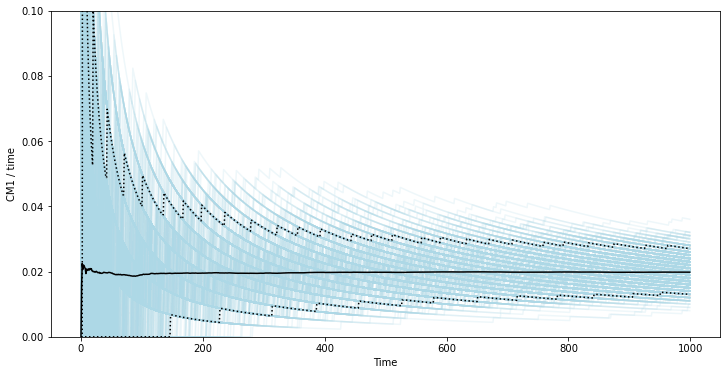

In [148]:
# Same, but with percentiles, to show non-parametric estimations (truer, but uglier)
N_POINTS = 1000
N_EXP = 1000
FREQ = 1/50

out = np.zeros(shape=(N_POINTS, N_EXP))
for t in range(1, N_POINTS):
    out[t, :] = (out[t-1, :]*(t-1) + (np.random.uniform(size=(1,N_EXP)) < FREQ)*1)/t

plt.figure(figsize=(12,6))
plt.plot(out, color='lightblue', alpha=0.2);
m = out.mean(axis=1)
lo = np.percentile(out, 5, axis=1)
hi = np.percentile(out, 95, axis=1)
plt.plot(m, 'k-');
plt.plot(hi, 'k:');
plt.plot(lo, 'k:');
plt.ylim(0, 0.1);
plt.xlabel('Time')
plt.ylabel('CM1 / time');

## Now the same, but CM2

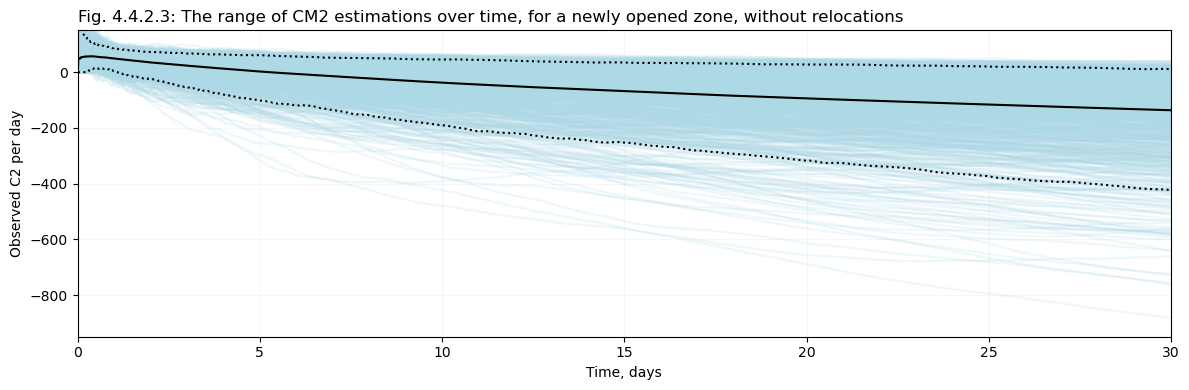

In [232]:
# Many CM1 trajectories, without
N_POINTS = 3000
N_EXP = 1000
POINTS_PER_DAY = 100
RENTALS_PER_DAY = 10  # Rentals per day
CM1_PER_TRIP = 5
CAR_COST = 20
RELOCATION_COST = 20
UPPER_FLEET_LIMIT = 10000000 # Aka, infinite

history = np.zeros(shape=(N_POINTS, N_EXP))
cars_inside = np.zeros(shape=(N_EXP))
n_relocations = 0
for t in range(1, N_POINTS):
    trips_in = (np.random.uniform(size=(1,N_EXP)) < RENTALS_PER_DAY/POINTS_PER_DAY)
    trips_out = (np.random.uniform(size=(1,N_EXP)) < RENTALS_PER_DAY/POINTS_PER_DAY)*(cars_inside>0)
    cars_inside += trips_in.flatten()*1 - trips_out.flatten()*1
    n_relocations = (cars_inside - UPPER_FLEET_LIMIT).clip(0, None)
    cars_inside = cars_inside.clip(0, UPPER_FLEET_LIMIT)
    new_income = (
        (trips_in*1 + trips_out*1)*CM1_PER_TRIP # Marginal profit, so including both in and out trips
        - cars_inside*CAR_COST/POINTS_PER_DAY
        - n_relocations*RELOCATION_COST
    )
    history[t, :] = (history[t-1, :]*(t-1) + new_income)/t
history = history*POINTS_PER_DAY
x = (np.arange(N_POINTS)+1)/POINTS_PER_DAY

plt.figure(figsize=(12,4))
plt.plot(x, history, color='lightblue', alpha=0.2);
m = history.mean(axis=1)
lo = np.percentile(history, 5, axis=1)
hi = np.percentile(history, 95, axis=1)
plt.plot(x, m, 'k-');
plt.plot(x, lo, 'k:');
plt.plot(x, hi, 'k:');
plt.grid(alpha=0.1)
rough_limits = (RENTALS_PER_DAY*CM1_PER_TRIP*3)
plt.ylim(None, rough_limits);
plt.xlim(0, N_POINTS // POINTS_PER_DAY);
plt.xlabel('Time, days')
plt.ylabel('Observed C2 per day');
plt.title("Fig. 4.4.2.3: The range of CM2 estimations over time, for a newly opened zone, without relocations",
          loc='left')

plt.tight_layout()
plt.savefig("../figures/04oa_04growth_02pilots_03cm2_norelo.png", dpi=300) # PNG as SVG becomes too huge

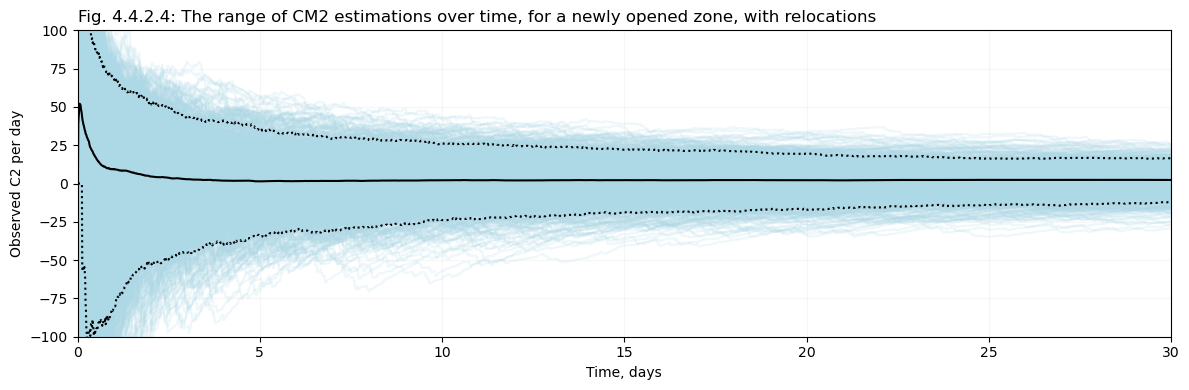

In [233]:
# Many CM1 trajectories, with relocations
N_POINTS = 3000
N_EXP = 1000
POINTS_PER_DAY = 100
RENTALS_PER_DAY = 10  # Rentals per day
CM1_PER_TRIP = 5
CAR_COST = 20
RELOCATION_COST = 20
UPPER_FLEET_LIMIT = 2
CI = stats.norm.ppf(0.95) # 95% confidence interval (roughly 1.65)

history = np.zeros(shape=(N_POINTS, N_EXP))
cars_inside = np.zeros(shape=(N_EXP))
n_relocations = 0
for t in range(1, N_POINTS):
    trips_in = (np.random.uniform(size=(1,N_EXP)) < RENTALS_PER_DAY/POINTS_PER_DAY)
    trips_out = (np.random.uniform(size=(1,N_EXP)) < RENTALS_PER_DAY/POINTS_PER_DAY)*(cars_inside>0)
    cars_inside += trips_in.flatten()*1 - trips_out.flatten()*1
    n_relocations = (cars_inside - UPPER_FLEET_LIMIT).clip(0, None)
    cars_inside = cars_inside.clip(0, UPPER_FLEET_LIMIT)
    new_income = (
        (trips_in*1 + trips_out*1)*CM1_PER_TRIP # Marginal profit, so including both in and out trips
        - cars_inside*CAR_COST/POINTS_PER_DAY
        - n_relocations*RELOCATION_COST
    )
    history[t, :] = (history[t-1, :]*(t-1) + new_income)/t
history = history*POINTS_PER_DAY
x = (np.arange(N_POINTS)+1)/POINTS_PER_DAY

plt.figure(figsize=(12,4))
plt.plot(x, history, color='lightblue', alpha=0.2);
m = history.mean(axis=1)
lo = np.percentile(history, 5, axis=1)
hi = np.percentile(history, 95, axis=1)
plt.plot(x, m, 'k-');
plt.plot(x, lo, 'k:');
plt.plot(x, hi, 'k:');
plt.grid(alpha=0.1)
rough_limits = (RENTALS_PER_DAY*CM1_PER_TRIP*2)
plt.ylim(-rough_limits, rough_limits);
plt.xlim(0, N_POINTS // POINTS_PER_DAY);
plt.xlabel('Time, days')
plt.ylabel('Observed C2 per day');
plt.title("Fig. 4.4.2.4: The range of CM2 estimations over time, for a newly opened zone, with relocations",
          loc='left')

plt.tight_layout()
plt.savefig("../figures/04oa_04growth_02pilots_04cm2_relos.png", dpi=300) # PNG as SVG becomes too huge

In [224]:
print("The CI by the end of this period:")
[lo[-1], m[-1], hi[-1]]

The CI by the end of this period:


[-13.051350450149496, 2.2029076358787862, 16.025675225075553]